## Машинное обучение на больших данных с использованием фреймворка Apache Spark и библиотеки SparkML

#### Запуск `Spark`-сессии

Подключаем необходимые библиотеки.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from pyspark.sql import SparkSession, DataFrame
from pyspark import SparkConf
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.ml.functions import vector_to_array
from pyspark.sql.functions import col, when, array, lit, explode, expr
from sklearn.metrics import roc_curve, auc as sklearn_auc, RocCurveDisplay, accuracy_score, precision_score, recall_score, f1_score

Сформируем объект конфигурации для `Apache Spark`, указав необходимые параметры.

In [2]:
def create_spark_configuration() -> SparkConf:
    """
    Создает и конфигурирует экземпляр SparkConf для приложения Spark.

    Returns:
        SparkConf: Настроенный экземпляр SparkConf.
    """
    
    conf = SparkConf()
    conf.setAppName("Loan_RandomForest")
    conf.setMaster("local[*]")
    # conf.set("spark.submit.deployMode", "client")
    # КРИТИЧЕСКИЕ настройки памяти
    conf.set("spark.driver.memory", "10g")           
    conf.set("spark.executor.memory", "15g")         
    conf.set("spark.memory.fraction", "0.8")        
    conf.set("spark.memory.storageFraction", "0.3") 
    
    # Настройки для больших данных
    conf.set("spark.sql.adaptive.enabled", "true")
    conf.set("spark.sql.adaptive.coalescePartitions.enabled", "true")
    conf.set("spark.sql.adaptive.skew.enabled", "true")
    conf.set("spark.sql.shuffle.partitions", "100")  # Уменьшил партиции

    return conf

Создаём сам объект конфигурации.

In [3]:
conf = create_spark_configuration()

Создаём и выводим на экран сессию `Apache Spark`. В процессе создания сессии происходит подключение к кластеру `Apache Hadoop`, что может занять некоторое время.

In [4]:
spark = SparkSession.builder.config(conf=conf).getOrCreate()
spark

#### Загрузка датасета

In [5]:
database_name = "database"

train_data_name = 'train_data'
path_features = f"{database_name}/train_features"

train_features = spark.read.parquet(path_features)

def print_df(df):
    return df.limit(20).toPandas().style\
    .set_properties(**{'text-align': 'left', 'max-width': '0', 'white-space': 'nowrap', 'overflow': 'hidden', 'text-overflow': 'ellipsis'})\
    .set_table_styles([{'selector': 'th', 'props': [('text-align', 'left')]}])\
    .format(precision=2)

In [6]:
train_features.printSchema()

root
 |-- id: integer (nullable = true)
 |-- features: vector (nullable = true)
 |-- flag: integer (nullable = true)
 |-- classWeight: double (nullable = true)



#### Постановка задачи

Для датасета, заданного представленными колонками, требуется построить модель RF для оценки факта появления дефолта по всем остальным признакам.

Для оценки качества обучения следует использовать метрики Precision и Recall. Оценить максимально возможное значение точности при полноте не менее 60%.

In [7]:
train_features, valid_features = train_features.randomSplit([0.8, 0.2], seed=42)

#### Обучение модели

In [8]:
train_features.printSchema()

root
 |-- id: integer (nullable = true)
 |-- features: vector (nullable = true)
 |-- flag: integer (nullable = true)
 |-- classWeight: double (nullable = true)



In [9]:
def train_random_forest(train_df, label_col="flag"):
    """
    Оптимизированные настройки для стабильности и ограниченных ресурсов.
    """
    
    from pyspark.ml.classification import RandomForestClassifier
    
    rf = RandomForestClassifier(
        featuresCol="features",
        labelCol=label_col,
        weightCol="classWeight",  # если используете веса
        numTrees=100,             # уменьшено для экономии памяти
        maxDepth=8,              # глубина - компромисс между качеством и памятью
        maxBins=32,              # уменьшено для экономии памяти
        subsamplingRate=0.8,     # используем subsampling
        featureSubsetStrategy="sqrt",  # sqrt от общего числа признаков
        minInstancesPerNode=10,  # предотвращает переобучение
        minWeightFractionPerNode=0.0,
        bootstrap=True,          # бутстрэппинг по умолчанию
        seed=42,
        impurity="gini",         # или "entropy"
        cacheNodeIds=False       # для экономии памяти
    )
    
    print("Обучение RandomForest на всех данных...")
    print(f"Количество деревьев: {rf.getNumTrees()}")
    print(f"Глубина деревьев: {rf.getMaxDepth()}")
    print(f"Subsampling rate: {rf.getSubsamplingRate()}")
    
    # Можно добавить мониторинг прогресса
    import time
    start_time = time.time()
    
    model = rf.fit(train_df)
    
    end_time = time.time()
    training_time = end_time - start_time
    print(f"Обучение завершено. Время: {training_time:.2f} секунд")
    
    # Вывод информации о модели
    print(f"Количество обученных деревьев: {model.getNumTrees}")
    print(f"Обучение было остановлено на итерации: {model.treeWeights[-1] if model.treeWeights else 'N/A'}")
    
    # Важность признаков
    print(f"Важность признаков (первые 10):")
    importances = model.featureImportances.toArray()
    for i, imp in enumerate(importances[:10]):
        print(f"  Признак {i}: {imp:.6f}")
    
    # Топ-признаки
    if len(importances) > 0:
        top_idx = importances.argmax()
        print(f"Самый важный признак: индекс {top_idx}, важность: {importances[top_idx]:.6f}")
    
    return model

In [10]:
model = train_random_forest(train_features)

Обучение RandomForest на всех данных...
Количество деревьев: 100
Глубина деревьев: 8
Subsampling rate: 0.8
Обучение завершено. Время: 296.22 секунд
Количество обученных деревьев: 100
Обучение было остановлено на итерации: 1.0
Важность признаков (первые 10):
  Признак 0: 0.003313
  Признак 1: 0.005623
  Признак 2: 0.036088
  Признак 3: 0.000099
  Признак 4: 0.008281
  Признак 5: 0.020080
  Признак 6: 0.040704
  Признак 7: 0.000664
  Признак 8: 0.013477
  Признак 9: 0.017861
Самый важный признак: индекс 6, важность: 0.040704


In [11]:
valid_pred = model.transform(valid_features)

# --- получаем probability и flag ---
prob_flag = valid_pred.select(
    vector_to_array(col("probability")).getItem(1).alias("p"),
    col("flag")
)

# --- создаём массив threshold'ов ---
thresholds = [t/100 for t in range(10, 91)]  # 0.10 ... 0.90
prob_flag = prob_flag.withColumn("thresholds", array(*[lit(t) for t in thresholds]))

# --- "взрываем" по threshold ---
exploded = prob_flag.select(
    "flag",
    "p",
    explode("thresholds").alias("t")
)

# --- делаем предсказание по threshold ---
exploded = exploded.withColumn("pred", (col("p") > col("t")).cast("int"))

# --- считаем TP, FP, FN по threshold ---
metrics = exploded.groupBy("t").agg(
    expr("sum(case when pred=1 and flag=1 then 1 else 0 end) as TP"),
    expr("sum(case when pred=1 and flag=0 then 1 else 0 end) as FP"),
    expr("sum(case when pred=0 and flag=1 then 1 else 0 end) as FN")
)

# --- добавляем precision и recall ---
metrics = metrics.withColumn("precision", col("TP") / (col("TP") + col("FP"))) \
                 .withColumn("recall", col("TP") / (col("TP") + col("FN")))

# --- фильтруем по recall ≥ 0.6 и выбираем лучший precision ---
best_row = metrics.filter(col("recall") >= 0.6) \
                  .orderBy(col("precision").desc()) \
                  .limit(1) \
                  .collect()[0]

print(f"Лучший threshold = {best_row['t']:.2f}, Precision = {best_row['precision']:.3f}, Recall = {best_row['recall']:.3f}")

Лучший threshold = 0.51, Precision = 0.063, Recall = 0.634


In [12]:
import time

# Замер времени
start_time = time.time()

# 1. Подготовка данных с оптимизацией
valid_df_opt = valid_features.cache()

valid_df_opt.count()  # Триггерим кэширование

# 2. Предсказание с мониторингом
print("Начинаем предсказание...")
valid_predictions = model.transform(valid_df_opt)

# Принудительный расчет и замер
valid_predictions.cache()
prediction_count = valid_predictions.count()
print(f"Рассчитано предсказаний: {prediction_count:,}")

# 3. Оценка метрик за один проход
print("Вычисление метрик...")

# AUC-ROC
evaluator = BinaryClassificationEvaluator(
    labelCol="flag",
    rawPredictionCol="rawPrediction",
    metricName="areaUnderROC"
)
auc = evaluator.evaluate(valid_predictions)
print(f"Validation AUC-ROC: {auc:.4f}")

def calculate_all_metrics(predictions: DataFrame):
    # Собираем все необходимые значения за один action
    preds_collected = predictions.select("flag", "prediction").collect()
    
    y_true = np.array([row.flag for row in preds_collected])
    y_pred = np.array([row.prediction for row in preds_collected])
    
    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "weightedPrecision": precision_score(y_true, y_pred, average='weighted'),
        "weightedRecall": recall_score(y_true, y_pred, average='weighted'),
        "f1": f1_score(y_true, y_pred, average='weighted')
    }
    
    return metrics

metrics = calculate_all_metrics(valid_predictions)
for name, value in metrics.items():
    print(f"{name}: {value:.4f}")

print(f"Общее время выполнения: {time.time() - start_time:.2f} секунд")

# 4. Очистка кэша (если нужно)
valid_df_opt.unpersist()
valid_predictions.unpersist()

Начинаем предсказание...
Рассчитано предсказаний: 599,277
Вычисление метрик...
Validation AUC-ROC: 0.6981
accuracy: 0.6208
weightedPrecision: 0.9475
weightedRecall: 0.6208
f1: 0.7358
Общее время выполнения: 23.08 секунд


DataFrame[id: int, features: vector, flag: int, classWeight: double, rawPrediction: vector, probability: vector, prediction: double]

Построение ROC кривой с sklearn...


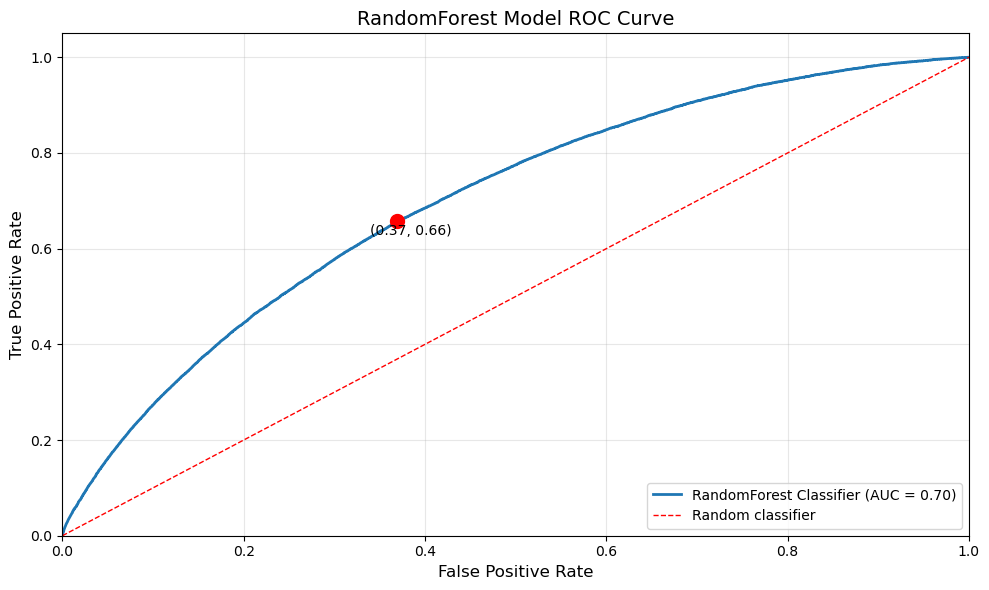

AUC: 0.6981
Best threshold: 0.5035
Best TPR: 0.6572
Best FPR: 0.3693


In [13]:
def plot_roc_with_sklearn(predictions, label_col="flag", title="ROC Curve"):
    """
    Использование sklearn для построения ROC
    """
    # Конвертируем в pandas для sklearn
    probs_labels = predictions.select(
        vector_to_array(col("probability")).getItem(1).alias("probability"),
        col(label_col).alias("label")
    ).toPandas()
    
    y_true = probs_labels["label"].values
    y_score = probs_labels["probability"].values
    
    # Вычисляем ROC
    fpr, tpr, thresholds = roc_curve(y_true, y_score)
    roc_auc = sklearn_auc(fpr, tpr)
    
    # Построение
    fig, ax = plt.subplots(figsize=(10, 6))
    roc_display = RocCurveDisplay(
        fpr=fpr, 
        tpr=tpr, 
        roc_auc=roc_auc,
        estimator_name="RandomForest Classifier"
    )
    
    roc_display.plot(ax=ax, linewidth=2)
    
    # Добавляем диагональ
    ax.plot([0, 1], [0, 1], 'r--', label='Random classifier', linewidth=1)
    
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate', fontsize=12)
    ax.set_ylabel('True Positive Rate', fontsize=12)
    ax.set_title(title, fontsize=14)
    ax.legend(loc="lower right")
    ax.grid(True, alpha=0.3)
    
    # Показываем лучший threshold (ближайший к верхнему левому углу)
    gmeans = np.sqrt(tpr * (1 - fpr))
    ix = np.argmax(gmeans)
    best_threshold = thresholds[ix]
    
    ax.plot(fpr[ix], tpr[ix], 'ro', markersize=10, 
            label=f'Best threshold = {best_threshold:.3f}')
    ax.annotate(f'({fpr[ix]:.2f}, {tpr[ix]:.2f})', 
                (fpr[ix], tpr[ix]), 
                textcoords="offset points", 
                xytext=(10,-10), 
                ha='center')
    
    plt.tight_layout()
    plt.show()
    
    print(f"AUC: {roc_auc:.4f}")
    print(f"Best threshold: {best_threshold:.4f}")
    print(f"Best TPR: {tpr[ix]:.4f}")
    print(f"Best FPR: {fpr[ix]:.4f}")
    
    return roc_auc, fpr, tpr, best_threshold

# Использование:
print("Построение ROC кривой с sklearn...")
auc_score, fpr, tpr, best_threshold = plot_roc_with_sklearn(
    valid_predictions,
    title="RandomForest Model ROC Curve"
)

In [14]:
import shutil
import os

def save_model(model, path="models/my_model", overwrite=True):
    """
    Сохраняет модель с обработкой существующих файлов
    """
    if overwrite:
        # Удаляем старую модель, если существует
        if os.path.exists(path):
            print(f"Удаляю старую модель: {path}")
            shutil.rmtree(path, ignore_errors=True)
    
    # Сохраняем новую модель
    model.save(path)
    print(f"Модель сохранена: {path}")
    return path

# Использование
save_model(model, "models/rf_model")

Модель сохранена: models/rf_model


'models/rf_model'

Не забываем завершать `Spark`-сессию.

In [15]:
spark.stop()